<a href="https://colab.research.google.com/github/KartikIyer27/MlOps-kartik-m25CSA025/blob/lab2_worksheet/kartik_m25csa025_lab2_worksheet_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install wandb thop


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import Dataset, DataLoader
from thop import profile
import wandb


In [20]:
wandb.init(
    project="mlops-lab-cifar10",
    name="simple-cnn-run",
    config={
        "epochs": 25,
        "batch_size": 128,
        "optimizer": "Adam",
        "lr": 0.001
    }
)


In [21]:
class CIFAR10Custom(Dataset):
    def __init__(self, train=True):
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        self.dataset = torchvision.datasets.CIFAR10(
            root='./data',
            train=train,
            download=True,
            transform=self.transform
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label


In [22]:
train_dataset = CIFAR10Custom(train=True)
test_dataset  = CIFAR10Custom(train=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [23]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)


In [25]:
dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input,))

print(f"FLOPs: {flops/1e6:.2f} MFLOPs")
print(f"Params: {params/1e6:.2f} Million")

wandb.log({
    "FLOPs (MFLOPs)": flops/1e6,
    "Parameters (M)": params/1e6
})


[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 6.65 MFLOPs
Params: 1.07 Million


In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [27]:
grad_flow_list = []
weight_flow_list = []


In [28]:
def log_gradients(model):
    grads = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grads.append(param.grad.norm().item())
    return np.mean(grads)

def log_weights(model):
    weights = []
    for param in model.parameters():
        weights.append(param.data.norm().item())
    return np.mean(weights)


In [29]:
for epoch in range(25):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    grad_flow = log_gradients(model)
    weight_flow = log_weights(model)

    grad_flow_list.append(grad_flow)
    weight_flow_list.append(weight_flow)


    wandb.log({
        "epoch": epoch,
        "train_loss": running_loss / len(train_loader),
        "train_accuracy": train_acc,
        "gradient_flow": grad_flow,
        "weight_flow": weight_flow
    })

    print(f"Epoch [{epoch+1}/25] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Acc: {train_acc:.2f}%")


Epoch [1/25] Loss: 1.3975 Acc: 50.16%
Epoch [2/25] Loss: 0.9914 Acc: 65.05%
Epoch [3/25] Loss: 0.8339 Acc: 70.82%
Epoch [4/25] Loss: 0.7194 Acc: 75.06%
Epoch [5/25] Loss: 0.6215 Acc: 78.27%
Epoch [6/25] Loss: 0.5178 Acc: 82.14%
Epoch [7/25] Loss: 0.4304 Acc: 85.12%
Epoch [8/25] Loss: 0.3376 Acc: 88.38%
Epoch [9/25] Loss: 0.2550 Acc: 91.36%
Epoch [10/25] Loss: 0.1849 Acc: 93.91%
Epoch [11/25] Loss: 0.1274 Acc: 95.99%
Epoch [12/25] Loss: 0.0911 Acc: 97.22%
Epoch [13/25] Loss: 0.0737 Acc: 97.68%
Epoch [14/25] Loss: 0.0663 Acc: 97.87%
Epoch [15/25] Loss: 0.0624 Acc: 97.96%
Epoch [16/25] Loss: 0.0564 Acc: 98.18%
Epoch [17/25] Loss: 0.0520 Acc: 98.29%
Epoch [18/25] Loss: 0.0420 Acc: 98.62%
Epoch [19/25] Loss: 0.0491 Acc: 98.39%
Epoch [20/25] Loss: 0.0333 Acc: 98.94%
Epoch [21/25] Loss: 0.0334 Acc: 98.94%
Epoch [22/25] Loss: 0.0430 Acc: 98.54%
Epoch [23/25] Loss: 0.0416 Acc: 98.60%
Epoch [24/25] Loss: 0.0368 Acc: 98.74%
Epoch [25/25] Loss: 0.0295 Acc: 99.03%


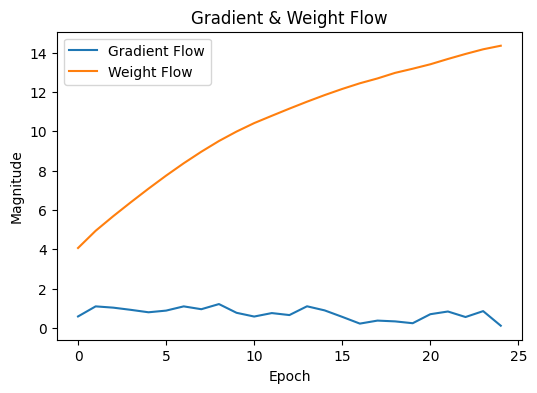

In [30]:
plt.figure(figsize=(6,4))
plt.plot(grad_flow_list, label="Gradient Flow")
plt.plot(weight_flow_list, label="Weight Flow")
plt.xlabel("Epoch")
plt.ylabel("Magnitude")
plt.title("Gradient & Weight Flow")
plt.legend()
plt.show()
